<a href="https://colab.research.google.com/github/Sambit24IISERTVM/DSC-212-Zachary-s-Karate-Club-Assignment/blob/main/DSC_212_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [810]:
#importing the required library and packages

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
karate_club_graph = nx.karate_club_graph() #Creating Zachery's Karate Club
from networkx.generators import community


In [811]:
#Initializing all the required parameters

n=34 # Total no of nodes
m=78 # Total no of edges
no_of_communities=1
community_list=list(range(0,n)) #List to store the communites
community_list=[community_list]
c=0 # No of nodes in the ommunity
iteration=1 # To store no of iterations
B=np.zeros((n,n))  # Global modularity matrix (n X n array)
A=np.zeros((n,n))  # Adjacency matrix (n X n array)
s=np.zeros(n)  # Community label vector (n X 1 array)
k=np.zeros(n)  # Node degree vector (n X 1 array)

In [812]:
#Function to find the Adjaceny Matrix

def adjacency_matrix():
  global A
  for r in range(n):
    for c in range(n):
      if karate_club_graph.has_edge(r,c):
        A[r,c]=1
      else:
        A[r,c]=0

In [813]:
#Function to find the degree vector 'k'

def degree_vector():
  global k
  for i, degree in karate_club_graph.degree():
    k[i] = degree

In [814]:
#Function to find the Global Modularity Matrix

def global_modularity_matrix():
  calculated_B = A - ((k.reshape(n,1)@ k.reshape(1,n))/(2*m))
  return calculated_B

In [815]:
# Function to calculate eigenvalues and eigenvectors of the global modularity matrix B

def eigen(M):
  vals_M, vecs_M = np.linalg.eig(M)
  vals_M = vals_M.real
  vecs_M = vecs_M.real
  return vals_M,vecs_M

In [816]:
#Computing the Community label vector

def community_label_vector(com,vals_M,vecs_M):
  c=len(com)
  global t
  t=np.zeros(c)
  eig_max=max(vals_M)
  eig_max_vec=vecs_M[:,np.where(vals_M==eig_max)]
  eig_max_vec=eig_max_vec.T
  eig_max_vec=eig_max_vec[0][0].tolist()
  if iteration==1:
    for i in range(c):
      if eig_max_vec[i]>=0:
        s[i]=1
      else:
        s[i]=-1
    return s
  elif iteration>1:
    for i in range(c):
      if eig_max_vec[i]>=0:
        t[i]=1
      else:
        t[i]=-1
    return t

In [817]:
#Function to identify new communities

def community_identification(commun, vals_M, vecs_M,i):
  global community_list
  v=community_label_vector(commun,vals_M,vecs_M)
  if i==1:
    community_1_indices=np.where(v==1)[0]
    community_1=[]
    for j in community_1_indices:
      community_1.append(commun[int(j)])
    community_2_indices=np.where(v==-1)[0]
    community_2=[]
    for j in community_2_indices:
      community_2.append(commun[int(j)])
    community_list[0]=community_1
    community_list.append(community_2)
  elif i>1:
    community_1_indices=np.where(v==1)[0]
    community_1=[]
    for j in community_1_indices:
      community_1.append(commun[int(j)])
    community_2_indices=np.where(v==-1)[0]
    community_2=[]
    for j in community_2_indices:
      community_2.append(commun[int(j)])
    community_list[community_list.index(commun)]=community_1
    community_list.append(community_2)
  return community_list

In [818]:
#Vizualizing the graphs

def vizualize_graphs():
  global community_list
  global n
  global iteration
  colour_list=['red','blue','green','yellow','orange','purple','pink', 'cyan', 'magenta', 'lime', 'brown', 'gray', 'olive']
  node_colors = ['lightgray'] * n
  for community_idx, community_members_array in enumerate(community_list):
    color_for_this_community = colour_list[community_idx % len(colour_list)]
    for node_id in community_members_array:
      if node_id < n:
        node_colors[node_id] = color_for_this_community
      else:
        print(f"Warning: Node ID {node_id} in community {community_idx} is out of graph bounds (0-{n-1}).")
  plt.figure(figsize=(10, 8))
  nx.draw_kamada_kawai(karate_club_graph, with_labels=True, node_color=node_colors, node_size=500, edge_color='black', font_size=10)
  plt.title(f"COMMUNITY SPLIT AFTER ITERATION NO:- {iteration}")
  plt.show()

In [819]:
#Function to find Restricted Modularity Matrix

def restricted_modularity_matrix(commun):
  adjacency_matrix()
  degree_vector()
  global c,Bc
  commun=np.array(commun)
  c = len(commun)
  Bc = np.zeros((c,c))
  for i in range(c):
    for j in range(c):
      Bc[i,j] = A[commun[i], commun[j]] - k[commun[i]]*k[commun[j]]/(2*m)
  return Bc

In [820]:
#Function to check if community split is possible or not

def community_split_check (vals_M,vecs_M):
  eig_max=max(vals_M)
  eig_max_vec=vecs_M[:,np.where(vals_M==eig_max)]
  eig_max_vec=eig_max_vec.T
  eig_max_vec=eig_max_vec[0][0].tolist()
  if max(vals_M) > 0:
    if min(eig_max_vec)>0:
      return 0
    elif max(eig_max_vec)<0:
      return 0
    else:
      return 1
  else:
    return 0

In [821]:
#Function to find the metrics for a specific community

def metrics(graph):
  degree_centrality = nx.degree_centrality(graph)
  betweenness_centrality = nx.betweenness_centrality(graph)
  closeness_centrality = nx.closeness_centrality(graph)
  clustering_coefficient = nx.clustering(graph)
  return degree_centrality, betweenness_centrality, closeness_centrality, clustering_coefficient

In [822]:
#Functions to store the metric values

def metrics_store(com,i,degree_centrality,betweness_centrality,closeness_centrality,clustering_coefficient):
  dc,dc1,bc,bc1,cc,cc1,ccf,ccf1={},{},{},{},{},{},{},{}
  for j in com:
    dec, bec, cec, clcf = metrics(karate_club_graph.subgraph(j))
    dc.update(dec)
    bc.update(bec)
    cc.update(cec)
    ccf.update(clcf)
  dc1[i]=dc
  bc1[i]=bc
  cc1[i]=cc
  ccf1[i]=ccf
  degree_centrality.update(dc1)
  betweness_centrality.update(bc1)
  closeness_centrality.update(cc1)
  clustering_coefficient.update(ccf1)
  return degree_centrality,betweness_centrality,closeness_centrality,clustering_coefficient

In [823]:
#Function to plot all the metric functions

def graph(d1, d2, d3, d4):
    dicts = [d1, d2, d3, d4]

    for idx, d in enumerate(dicts, start=1):
        iterations = sorted(d.keys())
        nodes = sorted({node for it in iterations for node in d[it].keys()})

        plt.figure(figsize=(10, 6))

        for node in nodes:
            values = [d[it].get(node, np.nan) for it in iterations]
            plt.plot(iterations, values, marker="o", alpha=0.7, label=f"Node {node}")
        if idx==1:
          plt.title(f"Degree Centrality", fontsize=16)
        elif idx==2:
          plt.title(f"Betweenness Centrality", fontsize=16)
        elif idx==3:
          plt.title(f"Closeness Centrality", fontsize=16)
        elif idx==4:
          plt.title(f"Clustering Coefficient", fontsize=16)
        plt.xlabel("No of iterations", fontsize=14)
        plt.ylabel("Value", fontsize=14)
        plt.xticks(iterations)
        plt.grid(alpha=0.3)

        # legend outside the plot
        plt.legend(title="Node", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

        plt.tight_layout()
        plt.show()

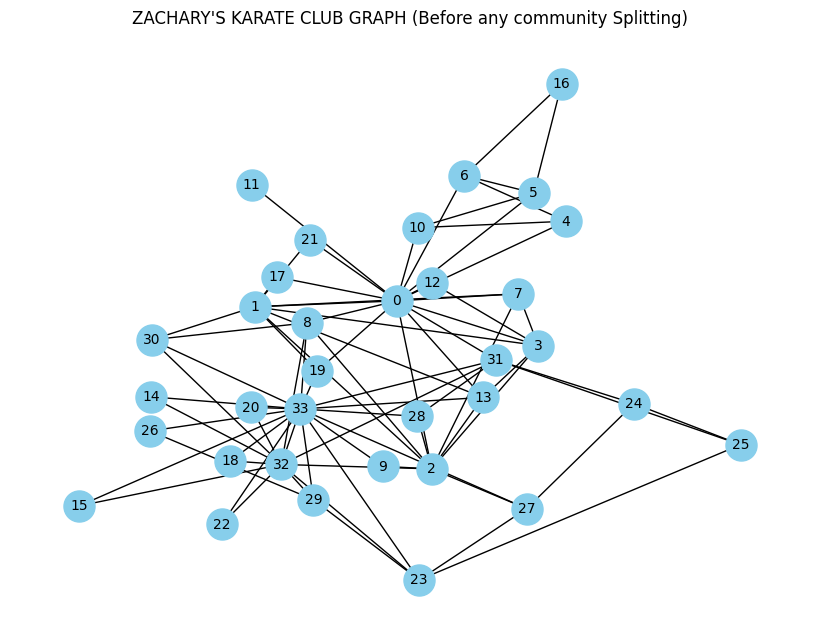





Community List after first iteration:

[[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]]





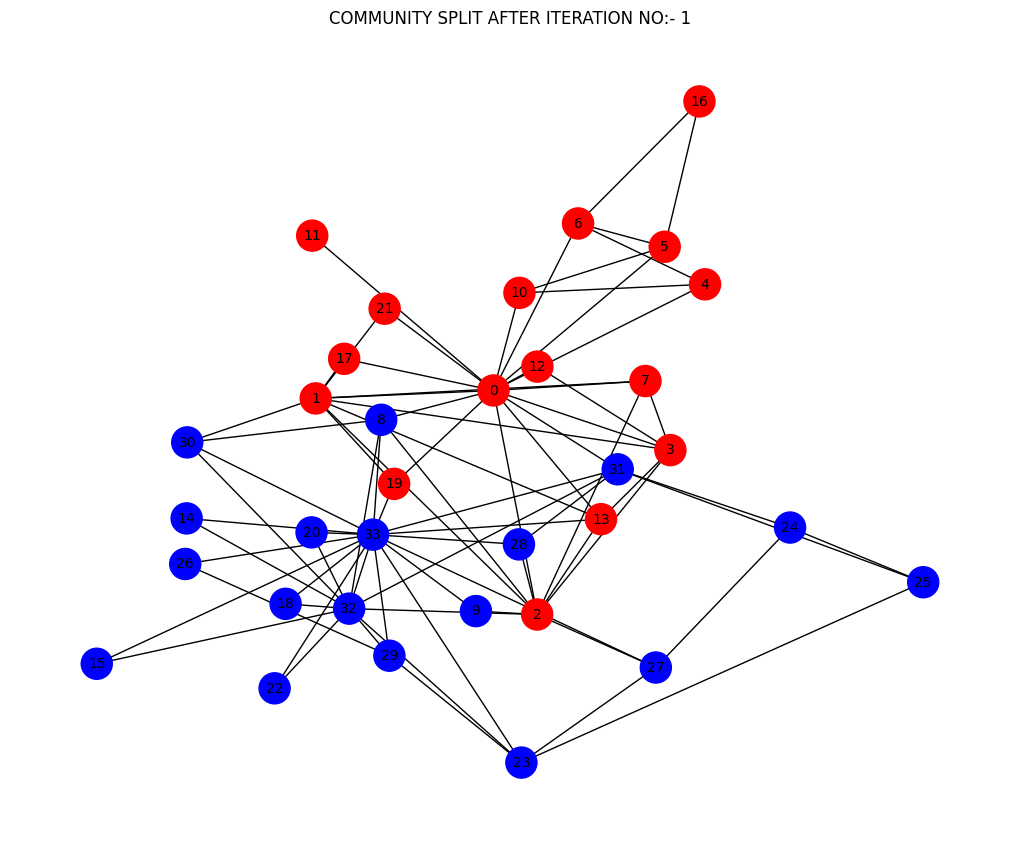

For ITERATION NO: 2



Community List after iteration no 2:

[[0, 1, 2, 3, 7, 12, 13, 17, 19, 21], [8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], [4, 5, 6, 10, 11, 16]]





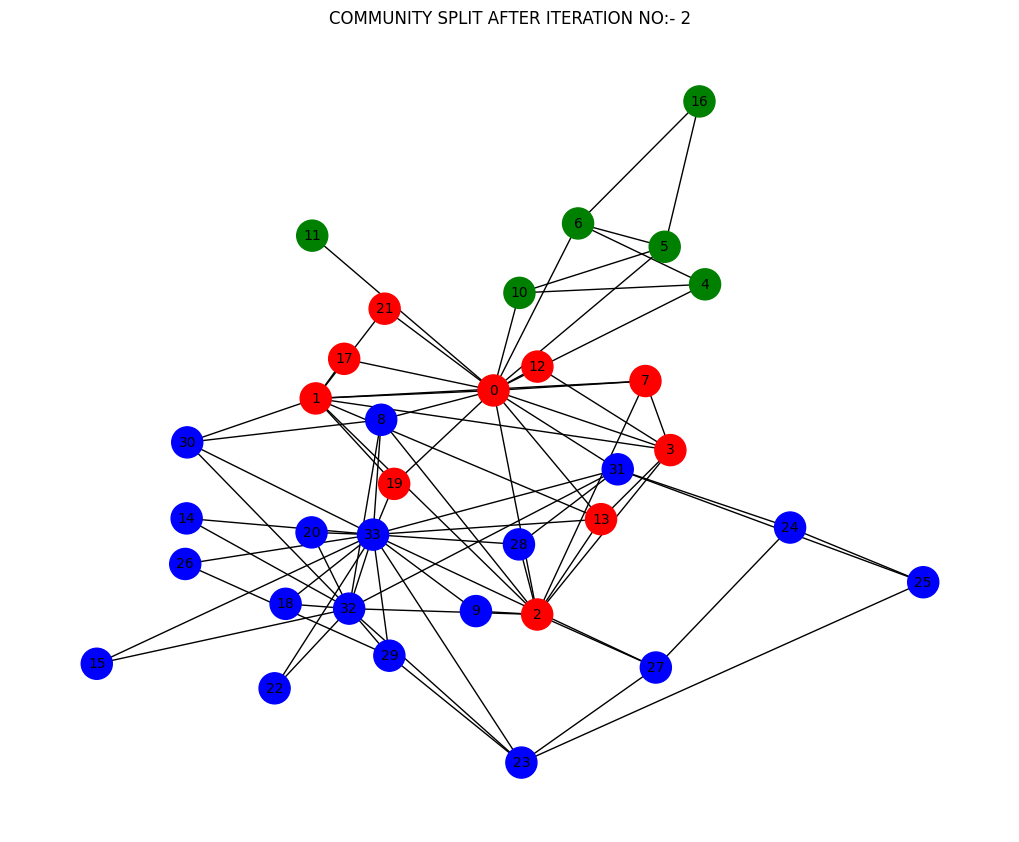





For ITERATION NO: 3



Community List after iteration no 3:

[[0, 1, 2, 3, 7, 12, 13, 17, 19, 21], [24, 25, 27, 28, 31], [4, 5, 6, 10, 11, 16], [8, 9, 14, 15, 18, 20, 22, 23, 26, 29, 30, 32, 33]]





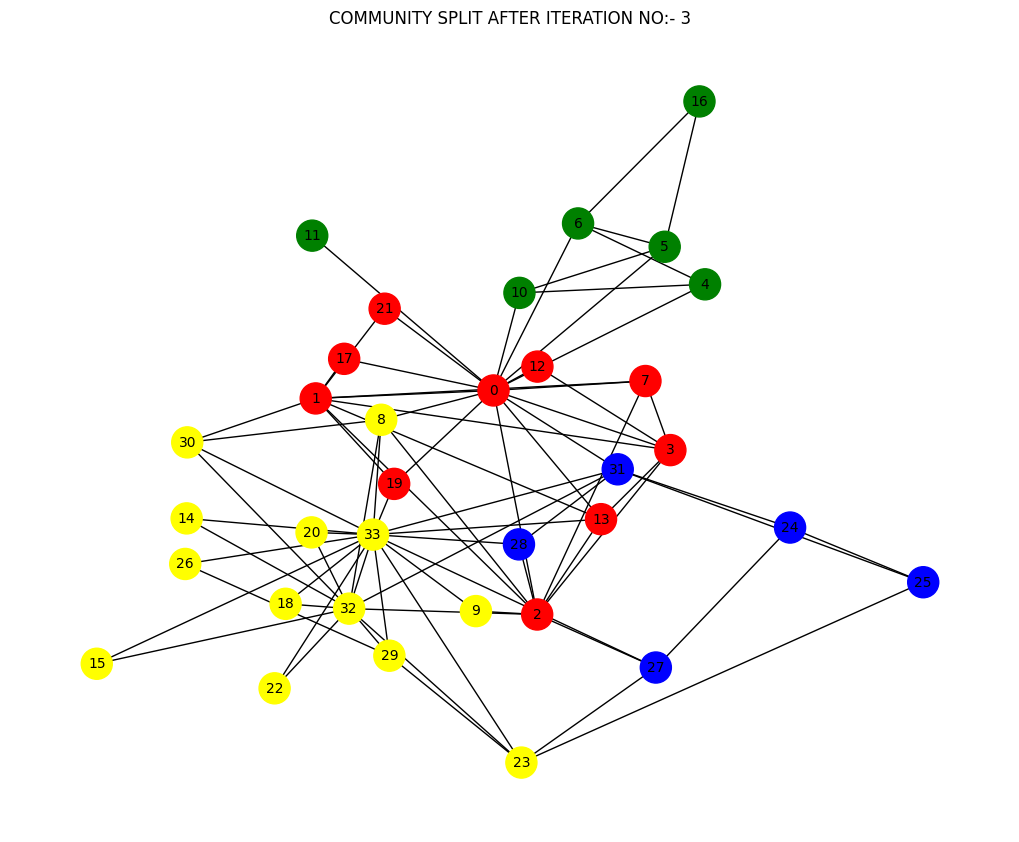





For ITERATION NO: 4



Community List after iteration no 4:

[[0, 1, 2, 3, 7, 12, 13, 17, 19, 21], [24, 25, 27, 28, 31], [11], [8, 9, 14, 15, 18, 20, 22, 23, 26, 29, 30, 32, 33], [4, 5, 6, 10, 16]]





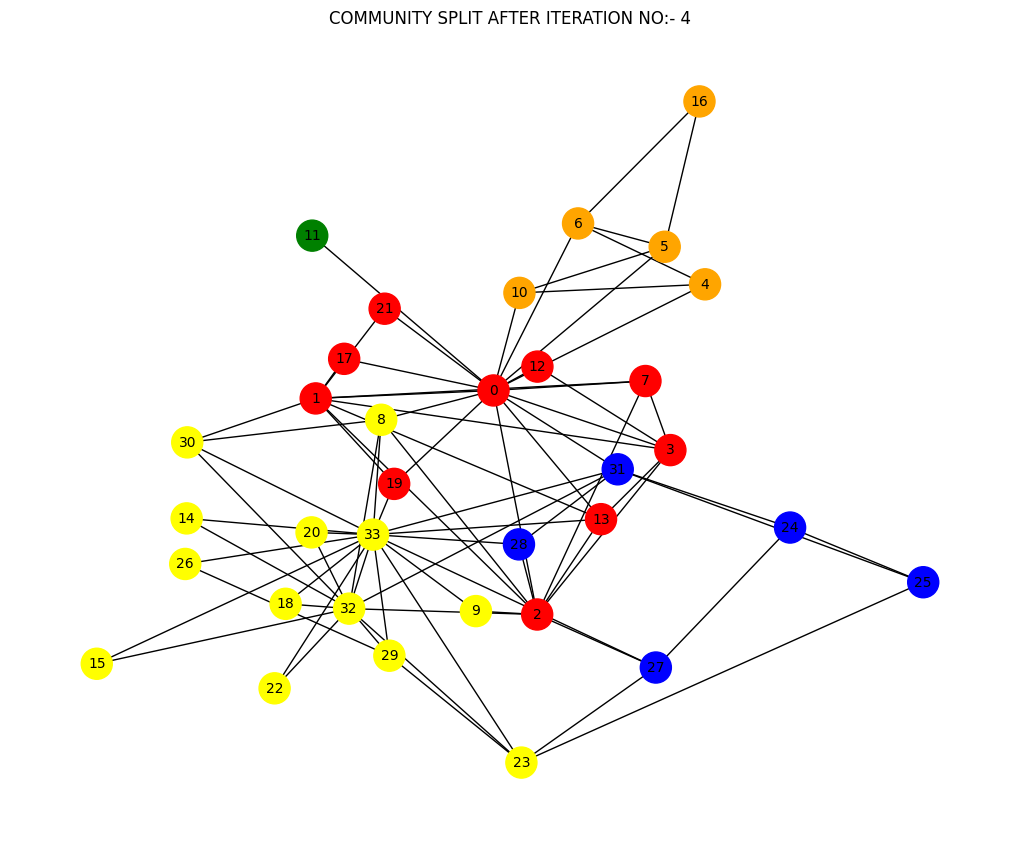





Final Community list:



Community 1: [0, 1, 2, 3, 7, 12, 13, 17, 19, 21]



Community 2: [24, 25, 27, 28, 31]



Community 3: [11]



Community 4: [8, 9, 14, 15, 18, 20, 22, 23, 26, 29, 30, 32, 33]



Community 5: [4, 5, 6, 10, 16]



Degree Centrality Dictionary:

{1: {0: 0.48484848484848486, 1: 0.2727272727272727, 2: 0.30303030303030304, 3: 0.18181818181818182, 4: 0.09090909090909091, 5: 0.12121212121212122, 6: 0.12121212121212122, 7: 0.12121212121212122, 8: 0.15151515151515152, 9: 0.06060606060606061, 10: 0.09090909090909091, 11: 0.030303030303030304, 12: 0.06060606060606061, 13: 0.15151515151515152, 14: 0.06060606060606061, 15: 0.06060606060606061, 16: 0.06060606060606061, 17: 0.06060606060606061, 18: 0.06060606060606061, 19: 0.09090909090909091, 20: 0.06060606060606061, 21: 0.06060606060606061, 22: 0.06060606060606061, 23: 0.15151515151515152, 24: 0.09090909090909091, 25: 0.09090909090909091, 26: 0.06060606060606061, 27: 0.12121212121212122, 28: 0.09090909090909091, 29: 0.121

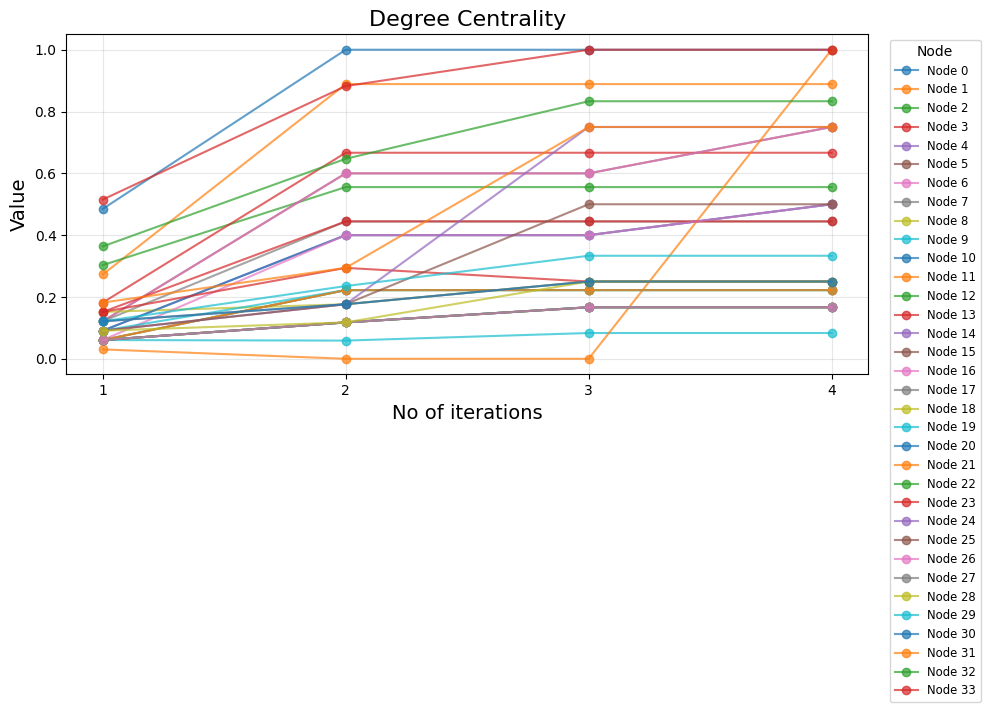

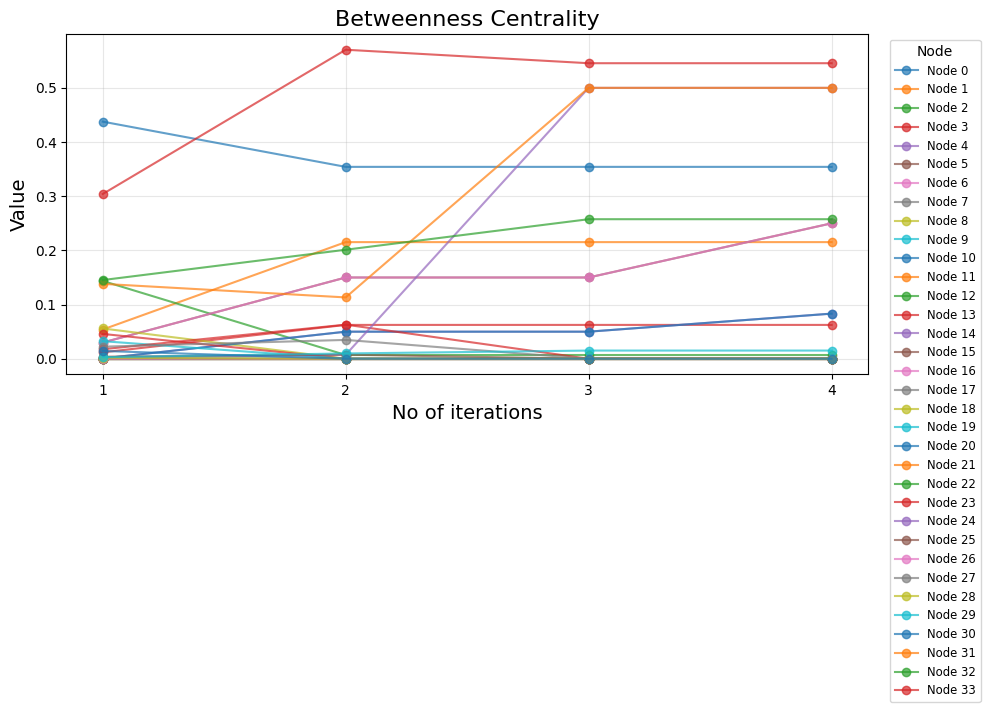

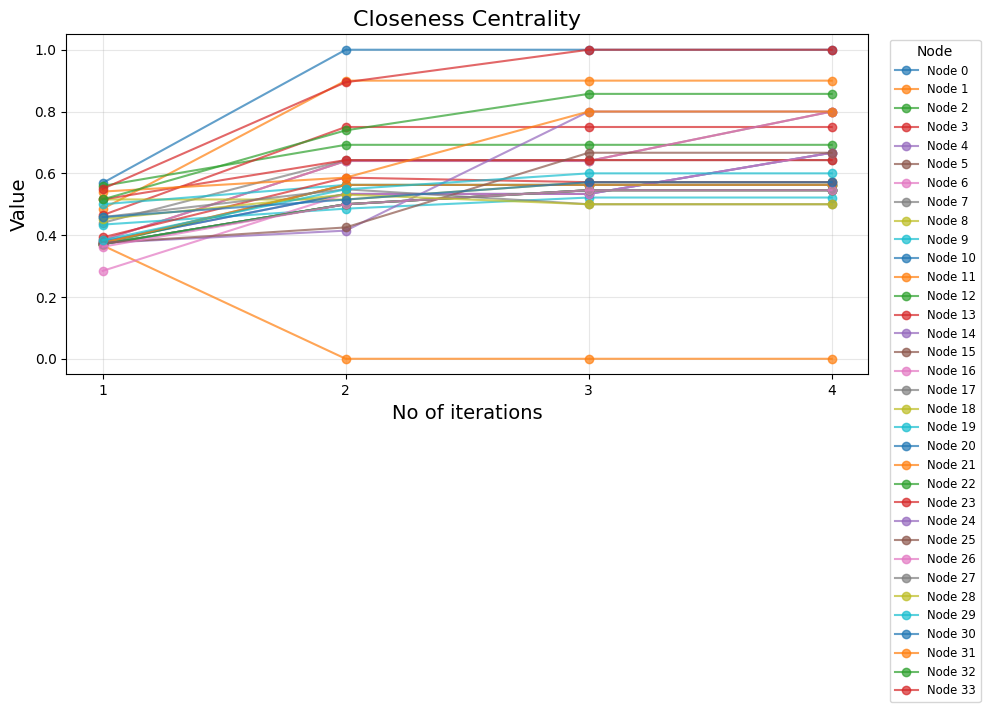

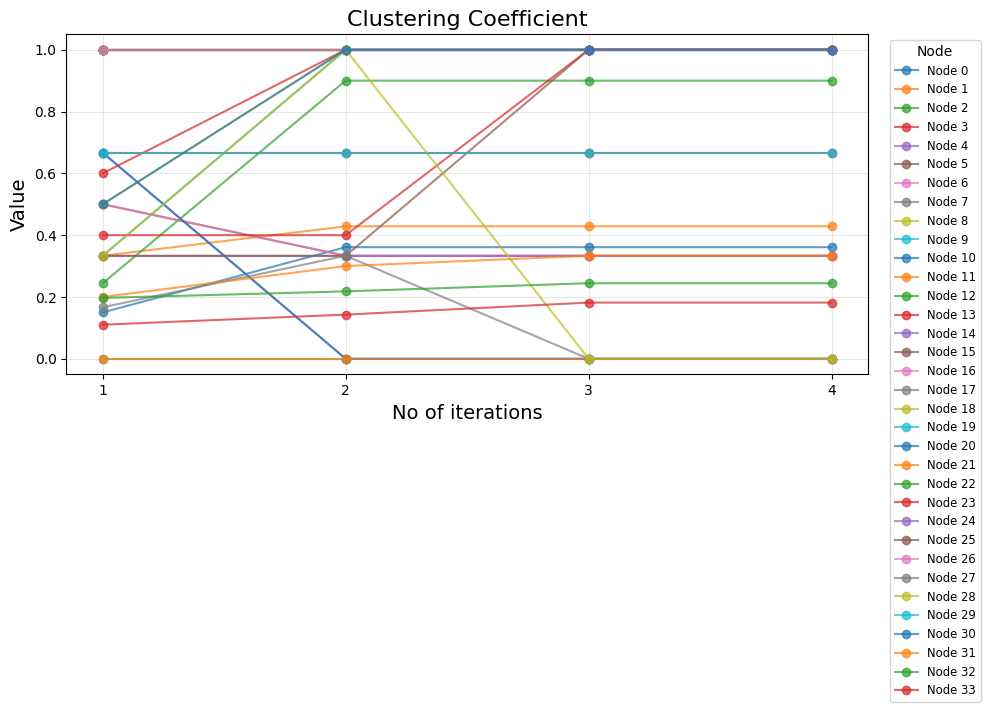

In [824]:
def __main__():
  global karate_club_graph
  global A
  global k
  global B
  global community_list
  global iteration
  plt.figure(figsize=(8, 6))
  nx.draw_kamada_kawai(karate_club_graph, with_labels=True, node_color='skyblue', node_size=500, edge_color='black', font_size=10)
  plt.title("ZACHARY'S KARATE CLUB GRAPH (Before any community Splitting)")
  plt.show()
  print("\n\n\n")
  adjacency_matrix()
  degree_vector()
  B = global_modularity_matrix()
  vals_B,vecs_B=eigen(B)
  degree_centralitly_dictionary,betweenness_centrality_dictionary,closeness_centrality_dictionary,clustering_coefficient_dictionary={},{},{},{}
  degree_centralitly_dictionary,betweenness_centrality_dictionary,closeness_centrality_dictionary,clustering_coefficient_dictionary=metrics_store(community_list,iteration,degree_centralitly_dictionary,betweenness_centrality_dictionary,closeness_centrality_dictionary,clustering_coefficient_dictionary)
  community_list = community_identification(community_list[0], vals_B, vecs_B,iteration)
  print(f"Community List after first iteration:\n\n{community_list}\n\n\n")
  vizualize_graphs()
  i = 0
  while i < len(community_list):
      current_community = community_list[i]
      Bc = restricted_modularity_matrix(current_community)
      vals_Bc,vecs_Bc=eigen(Bc)
      vals_Bc=vals_Bc.real
      vecs_Bc=vecs_Bc.real
      if community_split_check(vals_Bc,vecs_Bc) == 1:
          iteration=iteration+1
          print(f"For ITERATION NO: {iteration}\n\n\n")
          community_list=community_identification(current_community, vals_Bc, vecs_Bc,iteration)
          print(f"Community List after iteration no {iteration}:\n\n{community_list}\n\n\n")
          vizualize_graphs()
          print("\n\n\n")
          degree_centralitly_dictionary,betweenness_centrality_dictionary,closeness_centrality_dictionary,clustering_coefficient_dictionary=metrics_store(community_list,iteration,degree_centralitly_dictionary,betweenness_centrality_dictionary,closeness_centrality_dictionary,clustering_coefficient_dictionary)
      else:
          i += 1
  print(f"Final Community list:\n\n\n")
  for i in range(len(community_list)):
    print(f"Community {i+1}: {community_list[i]}\n\n\n")
  print(f"Degree Centrality Dictionary:\n\n{degree_centralitly_dictionary}\n\n\n")
  print(f"Betweenness Centrality Dictionary:\n\n{betweenness_centrality_dictionary}\n\n\n")
  print(f"Closeness Centrality Dictionary:\n\n{closeness_centrality_dictionary}\n\n\n")
  print(f"Clustering Coefficient Dictionary:\n\n{clustering_coefficient_dictionary}\n\n\n")
  print("Visualtization of Metric Functions:")
  graph(degree_centralitly_dictionary,betweenness_centrality_dictionary,closeness_centrality_dictionary,clustering_coefficient_dictionary)

__main__()

# FINAL COMMUNITY LIST WE GOT:

Community 1: [0, 1, 2, 3, 7, 12, 13, 17, 19, 21]

Community 2: [24, 25, 27, 28, 31]

Community 3: [11]

Community 4: [8, 9, 14, 15, 18, 20, 22, 23, 26, 29, 30, 32, 33]

Community 5: [4, 5, 6, 10, 16]


Although, the algorithm worked quite well but there is some discrepency remained with node 11 throughout all the iterations and finally it came out as a single community.

The nodes **0** and **33** are the **most consistently central** across all three centrality measures and all four network splits (Components 1, 2, 3, and 4). Node **32** also maintains a high degree of centrality, particularly in the overall network (Component 1).

The **community structure** strongly influences the metrics by creating a distinct division of labor between the **network-wide hubs (low clustering)** and the **locally embedded members (high clustering)**.

---

## 1. Consistent Central Nodes

The consistency of Nodes **0** and **33** across all components indicates they are structurally fundamental to the network, regardless of which subgraph (Component) is being analyzed.

| Centrality Measure | Overall Network (Comp 1) | Subgraph Examples (Comp 2, 3, 4) | Node Role |
| :--- | :--- | :--- | :--- |
| **Degree** (Connectedness) | **33**, **0**, 32 | **0**, **33** (often tied for 1st, or close 2nd) | **Highest number of direct connections**. They are the primary hubs. |
| **Betweenness** (Brokerage) | **0**, **33**, 32 | **33**, **0** (Node 33 consistently ranks 1st) | **Gatekeepers** controlling the flow of information. All shortest paths frequently run through them. |
| **Closeness** (Reachability) | **0**, 33, 2 | **0**, **33**, 32 (often tied for 1st) | **Most efficient nodes** for reaching all others, with the shortest average path length. |

### How Node Centrality Shifts Across Splits

The change in the *values* and *relative rank* of Node 0 and Node 33 in the splits (Components 2, 3, 4) suggests these splits represent different **communities or connected components**:

* **Node 0 and Node 33** often reach a maximum **Degree** and **Closeness** centrality of **1.0** in the splits, indicating that *within* those subgraphs, they are connected to almost every other node.
* In **Component 1** (likely the full network), **Node 0** is the top **Betweenness** broker (0.438).
* In the **Subgraphs (2, 3, 4)**, **Node 33** takes the clear lead in **Betweenness** (e.g., 0.570 in Comp 2), suggesting that while Node 0 is the universal "fastest" node, **Node 33** is the more critical **information bottleneck** in the localized community structures.

---

## 2. Influence of Community Structure (Clustering Coefficient)

The Clustering Coefficient (CC) reveals the structure around a node. A high CC (near 1.0) indicates a node's neighbors are also connected to each other (embedded in a dense clique/community), while a low CC indicates a **broker** role connecting different, less-connected groups.

### A. Centrality $\neq$ Local Cohesion (Nodes 0 and 33)

| Component | Node 0 CC | Node 33 CC | Interpretation |
| :--- | :--- | :--- | :--- |
| **1 (Overall)** | 0.150 | 0.110 | **Low Clustering** |
| **Subgraphs (2, 3, 4)** | $\approx 0.361$ | $\approx 0.143 - 0.182$ | **Still Low Clustering** |

The high Centrality (Degree, Betweenness, Closeness) combined with the **consistently low Clustering Coefficient** for Nodes $\mathbf{0}$ and $\mathbf{33}$ is the defining structural pattern:

* **Low CC confirms a Broker/Bridge Role:** Nodes 0 and 33 act as **connectors between different, distant communities** (low CC) rather than being deeply embedded in one tight local group. They are **structural holes** where information flow is concentrated.
* The fact that their CC remains low even in the subgraphs (Components 2, 3, 4) suggests that the subgraphs themselves are likely still large, star-like structures centered on these two primary nodes, rather than small, dense cliques.

### B. High Cohesion $\neq$ Centrality (e.g., Nodes 7, 12, 14)

Conversely, many low-centrality nodes (e.g., Nodes **7, 12, 14, 15, 17, 21**) have a Clustering Coefficient of **1.0** in Component 1 (and often in the other splits as well).

* These nodes are **embedded in perfect cliques**; all of their neighbors are mutually connected.
* Despite being perfectly integrated locally, their low centrality scores show they are **not important to the network as a whole**. They are local specialists with little influence or connection outside their small, tightly knit community.